# **Thông tin nhóm**
- Lớp: ML Labs 23KHDL1
- Nhóm: 3
- Sinh viên: 
    - 23127102 - Lê Quang Phúc
    - 23127212 - Nguyễn Quang Đăng Khoa
    - 23127241 - Đoàn Thành Phát
    - 23127332 - Trần Tiến Cường
    - 23127442 - Trầm Hữu Nhân


# **Model Implementation and Comparison**

## **1. Thư viện và thiết lập cấu hình chung**

In [1]:
import pandas as pd
import numpy as np
import ast
import re
import pickle
import joblib
import time
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, top_k_accuracy_score, accuracy_score, classification_report
from scipy.sparse import hstack, vstack, csr_matrix
from typing import Tuple, List, Optional, Dict
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import ParameterGrid
from io import BytesIO
from IPython.display import SVG, display

warnings.filterwarnings('ignore')


## **2. Model Architecture**

### 2.1 Paradigm
Hệ thống sử dụng Machine Learning truyền thống làm mô hình chính cho bài toán, 
nhóm áp dụng gợi ý dựa trên nội dung (content-based recommendation) và phát biểu lại bài toán 
dưới dạng Phân loại đa lớp (multi-class classification) bằng cách trích xuất đặc trưng từ bình luận 
người dùng để dự đoán địa điểm phù hợp nhất.

### 2.2 Model
Mô hình cốt lõi là `RandomForestClassifier` của thư viện `scikit-learn` với các thành phần pipeline như sau:

-  **Đặc trưng đầu vào**: Kết hợp giữa dữ liệu văn bản (Text) và dữ liệu dạng số (Numeric).

- **Xử lý dữ liệu**: Sử dụng `TfidfVectorizer` để chuyển đổi văn bản thành vector đặc trưng. Mô hình được giới hạn bởi `max_features` và `ngram_range`. Chuẩn hóa các đặc trưng số như `Score`, `Nums_comments`, `Price_min`, `Price_max`

- **Feature stacking**: Nối ma trận thưa `TF-IDF` và ma trận số tạo thành một vector đầu vào.

- **Đầu ra**: Chuyển đổi thành phân phối xác suất để xác định Top-5 địa điểm phù hợp nhất.

### 2.3 Pipeline
Từ dữ liệu thô đến hệ thống gợi ý hoàn chỉnh thông qua các bước sau:

- Tiền xử lý và chia tập dữ liệu
- Quá trình huấn luyện
- Tối ưu mô hình 
- Đánh giá và huấn luyện trên toàn bộ dữ liệu
- Suy luận và hậu xử lý cho bài toán gợi ý

### 2.4 Độ phù hợp với dữ liệu/bài toán
Việc lựa chọn `Random Forest` cho phương pháp xen kỹ này là hoàn toàn hợp lý vì:
- Dữ liệu bao gồm cả dữ liệu văn bản và dữ liệu số học. `Random Forest` xử lý tốt cả hai loại dữ liệu mà không cần chuẩn hóa sâu như neural network, chỉ cần các đặc trưng được vector hóa hợp lý.

- Đặc thù của `Random Forest` là một mô hình `Ensemble` bao gồm nhiều cây quyết định, các cây sẽ được huấn luyện độc lập giúp cho việc tận dụng được tối đa phần cứng lúc huấn luyện, giải quyết được sự mất cân bằng dữ liệu nhờ cơ chế bốc ngẫu nhiên và có khả năng tự đánh giá.

## **3. Tiền xử lý và chiến lược chia tập dữ liệu**
Lớp `DataPreprocessor` chịu trách nhiệm tiền xử lý dữ liệu bình luận địa điểm du lịch nhằm chuẩn bị dữ liệu đầu vào cho các mô hình Machine Learning trong hệ thống tư vấn du lịch Việt Nam: 
- Dữ liệu `comments` có nhiều định dạng khác nhau
- Các địa điểm thiếu bình luận 
- Phân phối dữ liệu không đồng đều giữa các địa điểm 

### 3.1 Trích xuất nội dung bình luận

Từ cột dữ liệu bình luận gốc được bóc tách và phân rã thành một danh sách các câu văn bản (`comment_parsed`). 

### 3.2 Tạo comment cho các địa điểm thiếu dữ liệu 

Nếu một địa điểm bị thiếu dữ liệu bình luận, nhóm sẽ lấy các thông tin từ dòng đó để ghép thành một câu miêu tả cơ bản như sau:`[Category] + giá từ + [Price_min] + tại + [Address]`.

### 3.3 Tái cấu trúc bộ dữ liệu
Dữ liệu gốc có cấu trúc là "1 địa điểm - nhiều bình luận", để mô hình có thể học từng ngữ cảnh một cách độc lập, nhóm sử dụng hàm `explode` để phân rã thành "1 địa điểm - 1 bình luận" theo từng dòng. 

### 3.4 Chiến lược chia tập dữ liệu
Do đặc thù của dữ liệu thực tế tồn tại hiện tượng mất cân bằng, có những địa điểm thu thập được rất ít bình luận (dưới 6 bình luận). Nếu chia ngẫu nhiên, các mẫu này có thể rơi vào tập `Validation` hoặc `Test` khiến mô hình mất đi dữ liệu để học, hoặc gây lỗi chia dữ liệu. 

Để giải quyết các vấn đề trên, nhóm đã thực hiện chiến lược phân chia dữ liệu như sau:
- Tách riêng các địa điểm có ít hơn 6 bình luận (`rare_location`).
- Sau khi dữ liệu hiếm bị loại ra, phần dữ liệu còn lại thay vì được chia ngẫu nhiên đơn thuần thì nhóm sẽ áp dụng lấy mẫu phân từng (`stratify=y`). Có nghĩa là mỗi khi chia ra theo tỷ lệ `70% Train - 15% Validation - 15% Test` nhưng vẫn đảm bảo được số lượng mẫu đồng đều trên cả 3 tập đối với mỗi địa điểm khác nhau.

In [2]:
class DataPreprocessor: 
    def __init__(self, file_path: str):
        self.file_path = file_path
        self.df_raw: Optional[pd.DataFrame] = None
        self.df_exploded: Optional[pd.DataFrame] = None
        self.df_train: Optional[pd.DataFrame] = None
        self.df_valid: Optional[pd.DataFrame] = None
        self.df_test: Optional[pd.DataFrame] = None
        
    def _parse_comments_string(self, comments_str: str) -> List[str]:
        def _clean_comment(value: object) -> str:
            text = str(value).strip()
            text = text.replace('\n', ' ').replace('\\n', ' ') # Xóa ký tự xuống dòng
            text = re.sub(r'\s+', ' ', text).strip() # Nén nhiều space thành 1
            return text
        
        # Trường hợp đã là list/tuple (dự phòng)
        if isinstance(comments_str, (list, tuple)):
            return [c for c in (_clean_comment(x) for x in comments_str) if c]

        # Trường hợp None hoặc rỗng
        if comments_str is None:
            return []

        comments_text = str(comments_str).strip()
        if comments_text == '' or comments_text == '[]' or comments_text.lower() == 'nan':
            return []

        # Parse theo Python list format
        try:
            parsed = ast.literal_eval(comments_text)  # Chuyển chuỗi thành object Python
            if isinstance(parsed, (list, tuple)):
                cleaned = []
                for item in parsed:
                    if item is None:
                        continue
                    item_text = _clean_comment(item)
                    # Xóa ngoặc nhọn bao ngoài comment nếu có (lỗi format thường gặp)
                    if item_text.startswith('{') and item_text.endswith('}'):
                        item_text = _clean_comment(item_text[1:-1])
                    if item_text:
                        cleaned.append(item_text)
                return cleaned
        except (ValueError, SyntaxError, TypeError):
            pass

        # Fallback: trích xuất từ format {comment 1}, {comment 2}
        matches = re.findall(r'\{(.*?)\}', comments_text, flags=re.DOTALL)
        if matches:
            return [c for c in (_clean_comment(m) for m in matches) if c]

        # Fallback cuối: coi toàn bộ chuỗi là 1 comment
        fallback = comments_text.strip('[]').strip()
        if fallback.startswith('{') and fallback.endswith('}'):
            fallback = fallback[1:-1]
        fallback = _clean_comment(fallback)
        return [fallback] if fallback else []
    
    def _generate_synthetic_comment(self, row: pd.Series) -> str:
        category = str(row.get('Category', 'Unknown'))
        price_min = str(row.get('Price_min', 0))
        address = str(row.get('Address', 'Unknown'))
        return f"{category} giá từ {price_min} VND tại {address}"
    
    def step1_explode_comments(self) -> pd.DataFrame:
        self.df_raw = pd.read_csv(self.file_path)
        
        df = self.df_raw.copy()
        
        df['Comments_parsed'] = df['Comments'].apply(self._parse_comments_string)
        
        total_comments = df['Comments_parsed'].apply(len).sum()
        
        df_exploded = df.explode('Comments_parsed', ignore_index=True)
        
        df_exploded = df_exploded.rename(columns={'Comments_parsed': 'Comment'})
        df_exploded = df_exploded.drop(columns=['Comments'])
        
        self.df_exploded = df_exploded

        return df_exploded
    
    def step2_fill_missing_comments(self) -> pd.DataFrame:
        if self.df_exploded is None:
            raise ValueError("Must run step 1 before running this step!")
        
        df = self.df_exploded.copy()
        
        missing_mask = df['Comment'].isna() | (df['Comment'] == '') | (df['Comment'].apply(lambda x: x == [] if isinstance(x, list) else False))
        num_missing = missing_mask.sum()
        
        if num_missing > 0:
            df.loc[missing_mask, 'Comment'] = df.loc[missing_mask].apply(
                self._generate_synthetic_comment, axis=1
            )
        
        remaining_missing = df['Comment'].isna().sum()
        
        self.df_exploded = df

        return df
    
    def step3_custom_splitting(self) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        if self.df_exploded is None:
            raise ValueError("Must run step 1and step 2 before splitting!")
        
        df = self.df_exploded.copy()
        
        comment_counts = df.groupby('Name').size()
        rare_locations = comment_counts[comment_counts < 6].index
        mask_rare = df['Name'].isin(rare_locations)

        df_train_rare = df[mask_rare]
        df_rest = df[~mask_rare]

        if df_rest.empty:
            self.df_train = df_train_rare.reset_index(drop=True)
            self.df_valid = pd.DataFrame()
            self.df_test = pd.DataFrame()
            return self.df_train, self.df_valid, self.df_test

        stratify_col = 'label_id' if 'label_id' in df_rest.columns else 'Name'
        y = df_rest[stratify_col]

        train_data, temp_data = train_test_split(
            df_rest,
            test_size=0.3,
            stratify=y,
            random_state=42
        )
        valid_data, test_data = train_test_split(
            temp_data,
            test_size=0.5,
            stratify=temp_data[stratify_col],
            random_state=42
        )

        if not df_train_rare.empty:
            train_data = pd.concat([train_data, df_train_rare], ignore_index=True)

        self.df_train = train_data.reset_index(drop=True)
        self.df_valid = valid_data.reset_index(drop=True)
        self.df_test = test_data.reset_index(drop=True)
        
        return self.df_train, self.df_valid, self.df_test
    
    def process(self) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        self.step1_explode_comments()
        self.step2_fill_missing_comments()
        self.step3_custom_splitting()
        self._print_final_summary()
        
        return self.df_train, self.df_valid, self.df_test
    
    def _print_final_summary(self):
        train_size = len(self.df_train) if self.df_train is not None else 0
        valid_size = len(self.df_valid) if self.df_valid is not None else 0
        test_size = len(self.df_test) if self.df_test is not None else 0
        total = train_size + valid_size + test_size
        
        print(f"Train: {train_size:}")
        print(f"Validation: {valid_size:}")
        print(f"Test : {test_size:}")

In [3]:
# Khởi tạo DataPreprocessor và xử lý dữ liệu
preprocessor = DataPreprocessor('../data/processed_data.csv')
df_train, df_valid, df_test = preprocessor.process()

# Lưu các tập dữ liệu
train_comments = df_train.copy()
valid_comments = df_valid.copy()
test_comments = df_test.copy()

Train: 97189
Validation: 20066
Test : 20067


### 3.5 Xây dựng đặc trưng cho mô hình
Vì mô hình `Random Forest` không hiểu text nên chúng ta cần phải biến văn bản thành vector số bằng `TF-IDF` và làm sạch dữ liệu để mô hình học được pattern. Đồng thời kết hợp thêm 1 vài feature của dữ liệu gốc để kết hợp với ma trận thưa để huấn luyện mô hình.

#### 3.5.1 Chuẩn hóa văn bản
Chuyển đổi tất cả bình luận sang chữ thường, loại bỏ ký tự đặc biệt nhưng giữ lại tiếng Việt có dấu. 
Điều này giúp mô hình tập trung vào nội dung thực sự của bình luận mà không bị ảnh hưởng bởi định dạng.

#### 3.5.2 Vector hóa văn bản bằng `TF-IDF`
Nhóm sử dụng thuật toán `TfidfVectorizer` để chuyển đổi các hồ sơ văn bản và câu truy vấn của người dùng thành các vector số học dạng ma trận thưa (sparse matrix). Kết quả sẽ là một ma trận có kích thước (`N_train, 5000`) đại diện mỗi dòng là hồ sơ ID của 1 địa điểm - điểm tương ứng của địa điểm đó với 5000 từ xuất hiện phổ biến và có ý nghĩa nhất trong toàn bộ tập dữ liệu.
* **TF (Term Frequency)** tính tần suất xuất hiện của từ khóa trong tài liệu.
* **IDF (Inverse Document Frequency)** đánh trọng số cao cho các từ khóa hiếm/đặc trưng và giảm trọng số của các từ vô nghĩa xuất hiện quá nhiều.
* Tham số `sublinear_tf=True` được áp dụng để tránh việc các từ khóa lặp lại quá nhiều lần làm sai lệch kết quả.

#### 3.5.3 Xử lý đặc trưng số học
Áp dụng `StandardScaler` và điền các giá trị thiếu cho 4 đặc trưng số học (`Score`, `Nums_commnents`, `Price_min`, `Price_max`)

#### 3.5.4 Hợp nhất đặc trưng 
Kết hợp ma trận thưa `TF-IDF` + `ma trận số học`  thành 1 ma trận duy nhất 


#### 3.5.5 Mã hóa nhãn
Sử dụng `LabelEncoder` để chuyển đổi mỗi tên địa điểm thành một số nguyên từ 0 đến n-1.


In [4]:
def normalize_text(text):
    text = str(text).strip().lower()
    text = re.sub(r'[^\w\sáàãạảăắằẵặẳâấầẫậẩéèẽẹẻêếềễệểíìĩịỉóòõọỏôốồỗộổơớờỡợởúùũụủưứừữựửýỳỹỵỷđ]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_comments['Comment'] = train_comments['Comment'].apply(normalize_text)
valid_comments['Comment'] = valid_comments['Comment'].apply(normalize_text)
test_comments['Comment'] = test_comments['Comment'].apply(normalize_text)

vectorizer = TfidfVectorizer(
    max_features=5000,          # Giới hạn số lượng từ/cụm từ được giữ lại, chỉ chọn những từ quan trọng nhất
    ngram_range=(1, 2),           # Quy định độ dài của n-gram, bao gồm cả từ đơn và cụm nhiều từ liên tiếp
    min_df=2,                # Ngưỡng tần suất xuất hiện tối thiểu của một từ trong toàn bộ văn bản
    max_df=0.95,                # Ngưỡng tần suất xuất hiện tối đa, loại bỏ những từ quá phổ biến
    sublinear_tf=True          # Áp dụng phép biến đổi log lên tần suất từ, giảm ảnh hưởng của từ xuất hiện quá nhiều
)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
X_train_text = vectorizer.fit_transform(train_comments['Comment'])
X_valid_text = vectorizer.transform(valid_comments['Comment'])
X_test_text = vectorizer.transform(test_comments['Comment'])

print(f"TF-IDF shape: {X_train_text.shape}")

# Chuẩn hóa đặc trưng số học
numeric_cols = ['Score', 'Nums_comments', 'Price_min', 'Price_max']

# Fill missing values
for col in numeric_cols:
    median_val = train_comments[col].median()
    train_comments[col] = train_comments[col].fillna(median_val)
    valid_comments[col] = valid_comments[col].fillna(median_val)
    test_comments[col] = test_comments[col].fillna(median_val)

# Chuẩn hóa (StandardScaler)
scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_comments[numeric_cols].values)
X_valid_num = scaler.transform(valid_comments[numeric_cols].values)
X_test_num = scaler.transform(test_comments[numeric_cols].values)

print(f"Numeric features shape: {X_train_num.shape}")

# Fix: Convert numeric to sparse BEFORE hstack
X_train_num = csr_matrix(X_train_num)
X_valid_num = csr_matrix(X_valid_num)
X_test_num = csr_matrix(X_test_num)

# Hợp nhất Text + Numeric
X_train = hstack([X_train_text, X_train_num])
X_valid = hstack([X_valid_text, X_valid_num])
X_test = hstack([X_test_text, X_test_num])

print(f"Features model: {X_train.shape}")

# Khớp định giáo ứng từ tập train
label_encoder = LabelEncoder()
label_encoder.fit(train_comments['Name'])

# Chuyển đổi target
y_train = label_encoder.transform(train_comments['Name'])
y_valid = label_encoder.transform(valid_comments['Name'])
y_test = label_encoder.transform(test_comments['Name'])

print(f"\nUnique classes: {len(label_encoder.classes_)}")
print(f"Class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
print(f"  - Min: {counts.min()}, Max: {counts.max()}, Mean: {counts.mean():.1f}")

TF-IDF shape: (97189, 5000)
Numeric features shape: (97189, 4)
Features model: (97189, 5004)

Unique classes: 5987
Class distribution:
  - Min: 1, Max: 449, Mean: 16.2


## **5. Quá trình huấn luyện**


{'max_depth': 10, 'min_samples_split': 40} -> Top-5 Accuracy: 0.1209 | Macro F1: 0.0242

Best params: {'max_depth': 10, 'min_samples_split': 40}

(n_estimators=20) Top-5 Accuracy: 0.0475 | Macro F1: 0.0066
(n_estimators=40) Top-5 Accuracy: 0.0705 | Macro F1: 0.0099
(n_estimators=60) Top-5 Accuracy: 0.0823 | Macro F1: 0.0119
Best n_estimators: 60


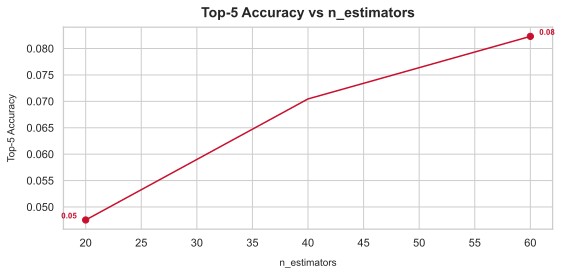

- Top-5 Accuracy (Valid): 0.1297
- Macro F1 (Valid): 0.0262


In [ ]:
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [20, 30, 40],
    'min_samples_leaf': [5, 7, 10]
}

grid = ParameterGrid(param_grid)
labels_all = np.arange(len(label_encoder.classes_))

best_params = None
best_top5 = -1.0
best_f1 = -1.0

tune_estimators = 50

for i, params in enumerate(grid, start=1):
    rf_tune = RandomForestClassifier(
        n_estimators=tune_estimators,
        random_state=42,
        n_jobs=-1,
        verbose=0,
        **params
    )
    rf_tune.fit(X_train, y_train)
    y_valid_proba = rf_tune.predict_proba(X_valid)
    y_valid_pred = np.argmax(y_valid_proba, axis=1)

    top5 = top_k_accuracy_score(y_valid, y_valid_proba, k=5, labels=labels_all)
    f1 = f1_score(y_valid, y_valid_pred, average='macro', zero_division=0)

    print(f"{params} -> Top-5 Accuracy: {top5:.4f} | Macro F1: {f1:.4f}")

    if (top5 > best_top5 + 1e-6) or (abs(top5 - best_top5) <= 1e-6 and f1 > best_f1):
        best_top5 = top5
        best_f1 = f1
        best_params = params

print(f"\nBest params: {best_params}")

# 2) Warm-start tăng dần số cây và dừng khi Top-5 không tăng nữa
max_trees = 300
step_trees = 20
start_trees = 20

rf_phase1 = RandomForestClassifier(
    n_estimators=start_trees,
    random_state=42,
    n_jobs=-1,
    verbose=0,
    warm_start=True,
    oob_score=True,
    **best_params
)

n_history = []
top5_history = []
f1_history = []

best_n = None
best_top5 = -1.0
best_f1 = -1.0

print()
for n_trees in range(start_trees, max_trees + 1, step_trees):
    rf_phase1.set_params(n_estimators=n_trees)
    rf_phase1.fit(X_train, y_train)
    
    # Sử dụng OOB probabilities thay cho tập Validation
    oob_proba = rf_phase1.oob_decision_function_
    
    # Lọc bỏ các mẫu có NaN (chưa từng là OOB khi số cây nhỏ)
    valid_oob_mask = ~np.isnan(oob_proba).any(axis=1)
    y_train_oob = y_train[valid_oob_mask]
    oob_proba_valid = oob_proba[valid_oob_mask]
    
    y_oob_pred = np.argmax(oob_proba_valid, axis=1)

    top5 = top_k_accuracy_score(y_train_oob, oob_proba_valid, k=5, labels=labels_all)
    f1 = f1_score(y_train_oob, y_oob_pred, average='macro', zero_division=0)

    n_history.append(n_trees)
    top5_history.append(top5)
    f1_history.append(f1)

    print(f"(n_estimators={n_trees}) Top-5 Accuracy: {top5:.4f} | Macro F1: {f1:.4f}")

    if top5 > best_top5 + 1e-6:
        best_top5 = top5
        best_f1 = f1
        best_n = n_trees
    else:
        break

if best_n is None:
    best_n = n_history[-1]

print(f"\nBest n_estimators: {best_n}")

# Refit mô hình với số cây tốt nhất để dùng cho các bước sau
rf_phase1 = RandomForestClassifier(
    n_estimators=best_n,
    random_state=42,
    n_jobs=-1,
    verbose=0,
    oob_score=True,
    **best_params
)
rf_phase1.fit(X_train, y_train)

# Đánh giá cuối cùng trên Valid
y_valid_pred_p1 = rf_phase1.predict(X_valid)
y_valid_proba_p1 = rf_phase1.predict_proba(X_valid)
valid_acc_p1 = accuracy_score(y_valid, y_valid_pred_p1)
valid_f1_p1 = f1_score(y_valid, y_valid_pred_p1, average='macro', zero_division=0)
valid_top5_p1 = top_k_accuracy_score(y_valid, y_valid_proba_p1, k=5, labels=labels_all)


# Vẽ biểu đồ OOB Top-5 Accuracy theo số cây
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(x=n_history, y=top5_history, label="Top-5 Accuracy", color="#C8102E", ax=ax, zorder=2)

ax.scatter([n_history[0], n_history[-1]], [top5_history[0], top5_history[-1]], color="#C8102E", s=40, zorder=3)

ax.text(n_history[0] - 0.8, top5_history[0], f"{top5_history[0]:.2f}", size=8, verticalalignment="bottom", horizontalalignment="right", fontweight="bold", color="#C8102E")

ax.text(n_history[-1] + 0.8, top5_history[-1], f"{top5_history[-1]:.2f}", size=8, verticalalignment="bottom", horizontalalignment="left", fontweight="bold", color="#C8102E")

ax.set_title("Top-5 Accuracy vs n_estimators", fontsize=14, pad=10, fontweight="bold", loc="center")
ax.set_xlabel("n_estimators", fontsize=10, labelpad=10)
ax.set_ylabel("Top-5 Accuracy", fontsize=10, labelpad=10)
ax.legend().remove()

plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format="svg", bbox_inches="tight")
display(SVG(data=buf.getvalue().decode("utf-8")))

buf.close()
plt.close(fig)

print(f"- Top-5 Accuracy (Valid): {valid_top5_p1:.4f}")
print(f"- Macro F1 (Valid): {valid_f1_p1:.4f}")

## **6. Đánh giá và huấn luyện trên toàn bộ mô hình**

### 6.1 Đánh giá trên tập kiểm tra

(n_estimators=20) Top-5 Accuracy: 0.0479 | Macro F1: 0.0066
(n_estimators=40) Top-5 Accuracy: 0.0703 | Macro F1: 0.0098
(n_estimators=60) Top-5 Accuracy: 0.0832 | Macro F1: 0.0120


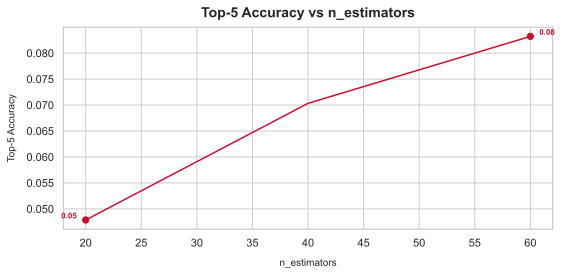

- Top-5 Accuracy (Test): 0.1358
- Macro F1 (Test): 0.0271


In [6]:
X_train_valid = vstack([X_train, X_valid])
y_train_valid = np.concatenate([y_train, y_valid])

# Create model (warm_start để theo dõi OOB theo số cây)
phase2_start_trees = 20
phase2_step_trees = 20
phase2_max_trees = best_n

rf_phase2 = RandomForestClassifier(
    n_estimators=phase2_start_trees,
    max_depth=best_params.get("max_depth"),
    min_samples_split=best_params.get("min_samples_split"),
    min_samples_leaf=best_params.get("min_samples_leaf", 1),
    random_state=42,
    n_jobs=-1,
    verbose=0,
    warm_start=True,
    oob_score=True
)

oob_top5_history = []
oob_f1_history = []
phase2_n_history = []

for n_trees in range(phase2_start_trees, phase2_max_trees + 1, phase2_step_trees):
    rf_phase2.set_params(n_estimators=n_trees)
    rf_phase2.fit(X_train_valid, y_train_valid)

    # Lấy OOB probabilities
    oob_proba = rf_phase2.oob_decision_function_
    
    # Lọc bỏ các mẫu có NaN (chưa từng là OOB, thường xuất hiện khi số cây nhỏ)
    valid_oob_mask = ~np.isnan(oob_proba).any(axis=1)
    y_valid_oob = y_train_valid[valid_oob_mask]
    oob_proba_valid = oob_proba[valid_oob_mask]
    
    # Tính toán các chỉ số
    y_oob_pred = np.argmax(oob_proba_valid, axis=1)
    top5 = top_k_accuracy_score(y_valid_oob, oob_proba_valid, k=5, labels=np.arange(len(label_encoder.classes_)))
    f1 = f1_score(y_valid_oob, y_oob_pred, average='macro', zero_division=0)

    phase2_n_history.append(n_trees)
    oob_top5_history.append(top5)
    oob_f1_history.append(f1)

    print(f"(n_estimators={n_trees}) Top-5 Accuracy: {top5:.4f} | Macro F1: {f1:.4f}")

# Optimization: Set n_jobs=4 trước predict
rf_phase2.set_params(n_jobs=4)

# Đánh giá trên Test C
y_test_pred_p2 = rf_phase2.predict(X_test)
y_test_proba_p2 = rf_phase2.predict_proba(X_test)

test_acc_p2 = accuracy_score(y_test, y_test_pred_p2)
test_f1_p2 = f1_score(y_test, y_test_pred_p2, average='macro', zero_division=0)
test_top5_p2 = top_k_accuracy_score(y_test, y_test_proba_p2, k=5, labels=np.arange(len(label_encoder.classes_)))

# Vẽ biểu đồ OOB theo số cây (Train + Valid)
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(x=phase2_n_history, y=oob_top5_history, label="OOB Top-5 Accuracy", color="#C8102E", ax=ax, zorder=2)

ax.scatter([phase2_n_history[0], phase2_n_history[-1]], [oob_top5_history[0], oob_top5_history[-1]], color="#C8102E", s=40, zorder=3)

ax.text(phase2_n_history[0] - 0.8, oob_top5_history[0], f"{oob_top5_history[0]:.2f}",
    size=8, verticalalignment="bottom", horizontalalignment="right", fontweight="bold", color="#C8102E")

ax.text(phase2_n_history[-1] + 0.8, oob_top5_history[-1], f"{oob_top5_history[-1]:.2f}",
    size=8, verticalalignment="bottom", horizontalalignment="left", fontweight="bold", color="#C8102E")

ax.set_title("Top-5 Accuracy vs n_estimators", fontsize=14, pad=10, fontweight="bold", loc="center")
ax.set_xlabel("n_estimators", fontsize=10, labelpad=10)
ax.set_ylabel("Top-5 Accuracy", fontsize=10, labelpad=10)
ax.legend().remove()

plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format="svg", bbox_inches="tight")
display(SVG(data=buf.getvalue().decode("utf-8")))

buf.close()
plt.close(fig)

print(f"- Top-5 Accuracy (Test): {test_top5_p2:.4f}")
print(f"- Macro F1 (Test): {test_f1_p2:.4f}")

### 6.2 Huấn luyện lại trên toàn bộ dữ liệu

In [ ]:
X_full = vstack([X_train, X_valid, X_test])
y_full = np.concatenate([y_train, y_valid, y_test])

# Create model (warm_start để theo dõi trend theo số cây, không dùng OOB để tránh OOM)
phase3_start_trees = 20
phase3_step_trees = 20
phase3_max_trees = best_n

rf_final = RandomForestClassifier(
    n_estimators=phase3_start_trees,
    max_depth=best_params.get("max_depth"),
    min_samples_split=best_params.get("min_samples_split"),
    min_samples_leaf=best_params.get("min_samples_leaf", 1),
    random_state=42,
    n_jobs=4,
    verbose=0,
    warm_start=True,
    oob_score=False
)

trend_top5_history = []
trend_f1_history = []
phase3_n_history = []

# Fixed subset (20%) để theo dõi trend
rng = np.random.default_rng(42)
trend_size = max(1, int(X_full.shape[0] * 0.1))
trend_idx = rng.choice(X_full.shape[0], size=trend_size, replace=False)
X_trend = X_full[trend_idx]
y_trend = y_full[trend_idx]

start_time = time.time()

for n_trees in range(phase3_start_trees, phase3_max_trees + 1, phase3_step_trees):
    rf_final.set_params(n_estimators=n_trees)
    rf_final.fit(X_full, y_full)

    # Predict trên fixed subset để đo trend
    trend_proba = rf_final.predict_proba(X_trend)
    trend_pred = np.argmax(trend_proba, axis=1)

    top5 = top_k_accuracy_score(
        y_trend,
        trend_proba,
        k=5,
        labels=np.arange(len(label_encoder.classes_))
    )
    f1 = f1_score(y_trend, trend_pred, average='macro', zero_division=0)

    phase3_n_history.append(n_trees)
    trend_top5_history.append(top5)
    trend_f1_history.append(f1)

    print(f"(n_estimators={n_trees}) Top-5 Accuracy: {top5:.4f} | Macro F1: {f1:.4f}")

end_time = time.time()
training_time = end_time - start_time

# Vẽ biểu đồ trend theo số cây (fixed subset)
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(x=phase3_n_history, y=trend_top5_history, label="Top-5 Accuracy", color="#C8102E", ax=ax, zorder=2)

ax.scatter([phase3_n_history[0], phase3_n_history[-1]], [trend_top5_history[0], trend_top5_history[-1]], color="#C8102E", s=40, zorder=3)

ax.text(phase3_n_history[0] - 0.8, trend_top5_history[0], f"{trend_top5_history[0]:.2f}",
    size=8, verticalalignment="bottom", horizontalalignment="right", fontweight="bold", color="#C8102E")

ax.text(phase3_n_history[-1] + 0.8, trend_top5_history[-1], f"{trend_top5_history[-1]:.2f}",
    size=8, verticalalignment="bottom", horizontalalignment="left", fontweight="bold", color="#C8102E")

ax.set_title("Top-5 Accuracy vs n_estimators", fontsize=14, pad=10, fontweight="bold", loc="center")
ax.set_xlabel("n_estimators", fontsize=10, labelpad=10)
ax.set_ylabel("Top-5 Accuracy", fontsize=10, labelpad=10)
ax.legend().remove()

plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format="svg", bbox_inches="tight")
display(SVG(data=buf.getvalue().decode("utf-8")))

buf.close()
plt.close(fig)

print(f"Training time: {training_time:.2f} seconds")

(n_estimators=20) Top-5 Accuracy: 0.1069 | Macro F1: 0.0227


MemoryError: Unable to allocate 1.23 GiB for an array with shape (27464, 1, 5987) and data type float64

# **7.Lưu checkpoint**
Sau khi hoàn thành huấn luyện, cần lưu tất cả các artifacts (mô hình, vectorizer, scaler, etc.) 
để có thể tải lại và sử dụng cho Inference mà không cần huấn luyện lại.

- **rf_model.pkl**: RandomForestClassifier đã huấn luyện đầy đủ 200 cây
- **tfidf_vectorizer.pkl**: TfidfVectorizer với 5000 features được huấn luyện trên tập Train
- **feature_scaler.pkl**: StandardScaler cho 4 đặc trưng số học
- **label_encoder.pkl**: LabelEncoder kết ánh tên địa điểm sang mã số
- **metadata_lookup.pkl**: Dictionary {Name → {Category, Address, Price_min, Price_max}}


In [ ]:
# Tạo metadata lookup table từ dữ liệu gốc
all_data = pd.concat([train_comments, valid_comments, test_comments], ignore_index=True)
metadata_lookup = {}

for _, row in all_data.drop_duplicates(subset=['Name']).iterrows():
    name = row['Name']
    metadata_lookup[name] = {
        'Category': row['Category'],
        'Address': row['Address'],
        'Price_min': row['Price_min'],
        'Price_max': row['Price_max']
    }

print(f"Metadata entries: {len(metadata_lookup)}")

# 1. Save Model
joblib.dump(rf_final, '../checkpoints/rf_model.pkl')
print(f"Saved Random Forest model at: ../checkpoints/rf_model.pkl")

# 2. Save Vectorizer
joblib.dump(vectorizer, '../checkpoints/rf_tfidf_vectorizer.pkl')
print(f"Saved TF-IDF vectorizer model at: ../checkpoints/rf_tfidf_vectorizer.pkl")

# 3. Save Scaler
joblib.dump(scaler, '../checkpoints/rf_feature_scaler.pkl')
print(f"Saved feature scaler at: ../checkpoints/rf_feature_scaler.pkl")

# 4. Save Label Encoder
joblib.dump(label_encoder, '../checkpoints/rf_label_encoder.pkl')
print(f"Saved feature scaler at: ../checkpoints/rf_label_encoder.pkl")

# 5. Save Metadata
joblib.dump(metadata_lookup, '../checkpoints/metadata_lookup.pkl')
print(f"Saved metadata_lookup at: ../checkpoints/rf_label_encoder.pkl")

## **8. Suy luận và hậu xử lý cho bài toán gợi ý**

## 8.1 Quá trình Inference (Suy luận)
Động cơ hoạt động của hệ thống gợi ý khi người dùng đưa ra một truy vấn:

1. **Nhận input từ người dùng**: Câu query bình luận từ người dùng
2. **Tiền xử lý query**: 
   - Chuẩn hóa văn bản (chữ thường, loại ký tự đặc biệt)
   - Vectorize bằng TfidfVectorizer
   - Tạo dummy numeric features (hoặc sử dụng giá trị mặc định)
   - Chuẩn hóa numeric features
   - Hợp nhất TF-IDF + numeric features
3. **Dự đoán**: Sử dụng rf_final.predict_proba() để lấy xác suất cho all classes
4. **Xếp hạng**: Sắp xếp theo xác suất giảm dần, lấy Top-K địa điểm
5. **Hậu xử lý**: 
   - Lọc theo Category (Dining/Attraction/Hotel)
   - Thêm metadata (Address, Price) vào kết quả
   - Trả về danh sách gợi ý

## 8.2 Demonstration - Load & Sử dụng Pickled Models với Inference Time Measurement

Mã code sau cho thấy cách sử dụng các file .pkl đã lưu để thực hiện Inference mà không cần huấn luyện lại mô hình. 
Đây là use case production khi triển khai hệ thống gợi ý trên server hoặc mobile.

In [ ]:
# Define normalize_text function (same as in data preprocessing)
def normalize_text(text):
    """Chuẩn hóa văn bản: chữ thường, loại ký tự đặc biệt"""
    text = str(text).strip().lower()
    text = re.sub(r'[^\w\sáàãạảăắằẵặẳâấầẫậẩéèẽẹẻêếềễệểíìĩịỉóòõọỏôốồỗộổơớờỡợởúùũụủưứừữựửýỳỹỵỷđ]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 1. Load all artifacts and measure loading time
print("\n Đang load các file .pkl...")
print("   Path: '../models/'")

# Check if models directory exists
models_dir = pathlib.Path('../models')
if not models_dir.exists():
    print(f" Warning: Models directory not found!")
    print(f"   Expected: {models_dir.resolve()}")
    print(f"   Current directory: {pathlib.Path('.').resolve()}")
    print(f"\n   SOLUTION:")
    print(f"   1. Make sure training cells in section 5 have been executed")
    print(f"   2. Make sure model saving cell in section 6 has been executed")
    print(f"   3. Then try running this cell again")
    print()

load_start_time = time.time()

try:
    rf_model = joblib.load('../models/rf_final_model.pkl')
    vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
    scaler = joblib.load('../models/feature_scaler.pkl')
    label_encoder = joblib.load('../models/label_encoder.pkl')
    metadata = joblib.load('../models/metadata_lookup.pkl')
except FileNotFoundError as e:
    print(f"\n ERROR: Could not load model files!")
    print(f"   {str(e)}")
    raise

load_time = time.time() - load_start_time
print(f"\n✓ Tất cả models đã được load (Thời gian: {load_time:.3f} giây)")

# Tạo lookup mapping giữa label index và metadata
location_metadata = {}
for idx, name in enumerate(label_encoder.classes_):
    if name in metadata:
        location_metadata[idx] = {
            'name': name,
            'category': metadata[name].get('Category', 'Unknown'),
            'address': metadata[name].get('Address', 'Unknown'),
            'price_min': metadata[name].get('Price_min', 0),
            'price_max': metadata[name].get('Price_max', 0)
        }
    else:
        location_metadata[idx] = {
            'name': name,
            'category': 'Unknown',
            'address': 'Unknown',
            'price_min': 0,
            'price_max': 0
        }

# 2. Định nghĩa hàm Inference với tracking
def infer_recommendations(user_query, metadata_dict, track_time=True):
    """Dự đoán gợi ý từ user query và track inference time
    
    Args:
        user_query: Câu query từ người dùng
        metadata_dict: Dictionary metadata
        track_time: Nếu True, trả về thời gian inference
        
    Returns:
        DataFrame với cột [Name, Category, Probability]
        và (optional) inference time in milliseconds
    """
    
    inference_start = time.time()
    
    # Tiền xử lý query
    processed = normalize_text(user_query)
    
    # Vectorize (TF-IDF transform)
    X_text = vectorizer.transform([processed])
    
    # Tạo numeric features (sử dụng giá trị mặc định)
    X_num = np.array([[4.5, 50, 5000000, 15000000]]).reshape(1, -1)
    X_num = scaler.transform(X_num)
    X_num = csr_matrix(X_num)
    
    # Hợp nhất
    X_query = hstack([X_text, X_num])
    
    # Dự đoán
    proba = rf_model.predict_proba(X_query)[0]
    
    # Lấy Top-5
    top_indices = np.argsort(proba)[::-1][:5]
    names = label_encoder.inverse_transform(top_indices)
    
    results = []
    for idx, name in zip(top_indices, names):
        results.append({
            'Name': name,
            'Category': metadata_dict.get(name, {}).get('Category', 'Unknown'),
            'Probability': proba[idx]
        })
    
    inference_time = (time.time() - inference_start) * 1000  # Convert to milliseconds
    
    result_df = pd.DataFrame(results)
    
    if track_time:
        return result_df, inference_time
    else:
        return result_df

# 3. Test inference và measure time
print("\n" + "=" * 80)
print("INFERENCE TIME MEASUREMENT")
print("=" * 80)

test_queries = [
    "Nhà hàng Việt Nam ở Hồ Chí Minh",
    "Khách sạn 4 sao gần trung tâm",
    "Địa điểm du lịch nổi tiếng",
    "Quán cà phê yên tĩnh",
    "Ăn sáng ngon rẻ"
],
inference_times = []

for query in test_queries:
    recommendations, inf_time = infer_recommendations(query, metadata, track_time=True)
    inference_times.append(inf_time)

avg_inference_time = np.mean(inference_times)
min_inference_time = np.min(inference_times)
max_inference_time = np.max(inference_times)

print(f"\nINFERENCE TIME STATISTICS:")
print(f"   • Average: {avg_inference_time:.2f} ms")
print(f"   • Min: {min_inference_time:.2f} ms")
print(f"   • Max: {max_inference_time:.2f} ms")
print(f"   • Total for {len(test_queries)} queries: {sum(inference_times):.2f} ms")
print(f"   • Throughput: ~{1000/avg_inference_time:.0f} queries/second")

# 4. Demo recommendations
print("\n" + "=" * 80)
print("EXAMPLE OUTPUT")
print("=" * 80)

query = "Tôi muốn ăn pizza ở Quận 1"
recommendations, inf_time = infer_recommendations(query, metadata, track_time=True)

print(f"\nQuery: \"{query}\"")
print(f"Inference Time: {inf_time:.2f} ms\n")
print(recommendations.to_string(index=False))


# 9. ĐÁNH GIÁ CHI TIẾT - STORAGE COST & MODEL PARAMETERS

Kích thước lưu trữ (disk space) và số lượng parameters của mô hình:

In [ ]:
# STORAGE COST
checkpoint_path = "../models/rf_final_model.pkl"
storage_cost_mb = os.path.getsize(checkpoint_path) / (1024 * 1024) if os.path.exists(checkpoint_path) else 0

# MODEL PARAMETERS
total_params = rf_final.n_estimators * len(label_encoder.classes_) * rf_final.n_features_in_

print(f"\n Storage cost: {storage_cost_mb:.2f} MB")
print(f" Total parameters: {total_params:,}")
print()
